/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 93ms/step - accuracy: 0.3033 - loss: 1.8748 - val_accuracy: 0.4879 - val_loss: 1.4240
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.5234 - loss: 1.3224 - val_accuracy: 0.5807 - val_loss: 1.1819
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 80s 93ms/step - accuracy: 0.5891 - loss: 1.1572 - val_accuracy: 0.6076 - val_loss: 1.1064
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.6278 - loss: 1.0569 - val_accuracy: 0.6374 - val_loss: 1.0279
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.6590 - loss: 0.9722 - val_accuracy: 0.6611 - val_loss: 0.9694
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6648 - loss: 0.9581
Test Accuracy: 0.6583999991416931
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step


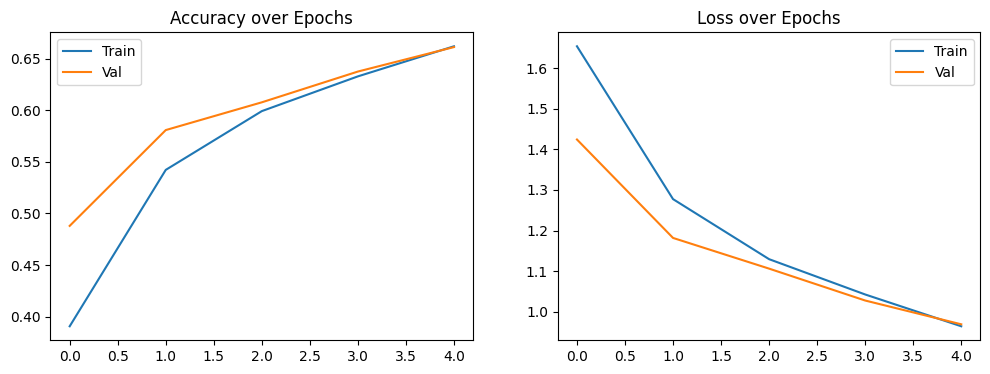

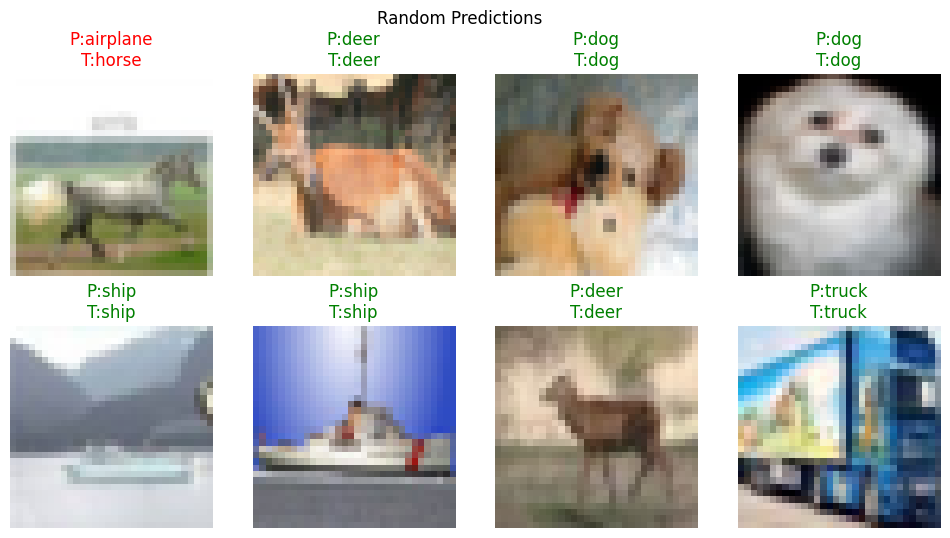


Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.60      0.67      1000
           1       0.74      0.84      0.78      1000
           2       0.55      0.54      0.54      1000
           3       0.50      0.44      0.46      1000
           4       0.59      0.58      0.59      1000
           5       0.49      0.67      0.57      1000
           6       0.70      0.77      0.73      1000
           7       0.80      0.65      0.72      1000
           8       0.75      0.79      0.77      1000
           9       0.78      0.71      0.74      1000

    accuracy                           0.66     10000
   macro avg       0.67      0.66      0.66     10000
weighted avg       0.67      0.66      0.66     10000


Experiment Completed Successfully ✅


In [2]:
# ============================
# EXPERIMENT 8 - CNN (CIFAR-10)
# Upgraded but Clean Version
# ============================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report
import seaborn as sns

# Load Dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train, x_test = x_train/255.0, x_test/255.0

class_names = ["airplane","automobile","bird","cat",
               "deer","dog","frog","horse","ship","truck"]

# Build CNN
model = keras.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history = model.fit(x_train,y_train,
                    epochs=5,
                    batch_size=64,
                    validation_split=0.2,
                    verbose=1)

# Evaluate
test_loss, test_acc = model.evaluate(x_test,y_test)
print("Test Accuracy:", test_acc)

# Predictions
probabilities = model.predict(x_test)
y_pred = np.argmax(probabilities,axis=1)

# --------------------------
# Accuracy & Loss Plot
# --------------------------
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Train')
plt.plot(history.history['val_accuracy'],label='Val')
plt.title("Accuracy over Epochs")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Train')
plt.plot(history.history['val_loss'],label='Val')
plt.title("Loss over Epochs")
plt.legend()

plt.show()

# --------------------------
# Random Predictions
# --------------------------
plt.figure(figsize=(12,6))
for i in range(8):
    idx = np.random.randint(0,len(x_test))
    plt.subplot(2,4,i+1)
    plt.imshow(x_test[idx])
    pred = y_pred[idx]
    true = y_test[idx][0]
    color = "green" if pred==true else "red"
    plt.title(f"P:{class_names[pred]}\nT:{class_names[true]}",color=color)
    plt.axis("off")
plt.suptitle("Random Predictions")
plt.show()

# --------------------------
# Classification Report
# --------------------------
print("\nClassification Report:\n")
print(classification_report(y_test,y_pred))

print("\nExperiment Completed Successfully ✅")